In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [16]:
path = rf'D:\arturo_sim\simulaciones\analisis_sensibilidad\data\mesh0_roll.xlsx'

In [17]:
df = pd.read_excel(path, header = 1).drop(0)

In [18]:
df

,Frequencies),Amplitude
1,0.002441,0.000046
2,0.004883,0.000047
3,0.007324,0.000053
4,0.009766,0.000022
5,0.012207,0.000039
...,...,...
2044,4.990234,0.000001
2045,4.992676,0.000001
2046,4.995117,0.000001
2047,4.997559,0.000001


In [19]:
ancho_banda = df['Frequencies)'][2]-df['Frequencies)'][1]
ancho_banda

0.0024414062500001388

In [20]:
df['density'] = 0.5 * (df['Amplitude']**(2)*ancho_banda)
df

,Frequencies),Amplitude,density
1,0.002441,0.000046,2.559551e-12
2,0.004883,0.000047,2.730989e-12
3,0.007324,0.000053,3.422860e-12
4,0.009766,0.000022,5.763763e-13
5,0.012207,0.000039,1.843793e-12
...,...,...,...
2044,4.990234,0.000001,1.226118e-15
2045,4.992676,0.000001,1.225688e-15
2046,4.995117,0.000001,1.225977e-15
2047,4.997559,0.000001,1.225795e-15


In [21]:
frequency = df['Frequencies)'].values
density = df['density'].values

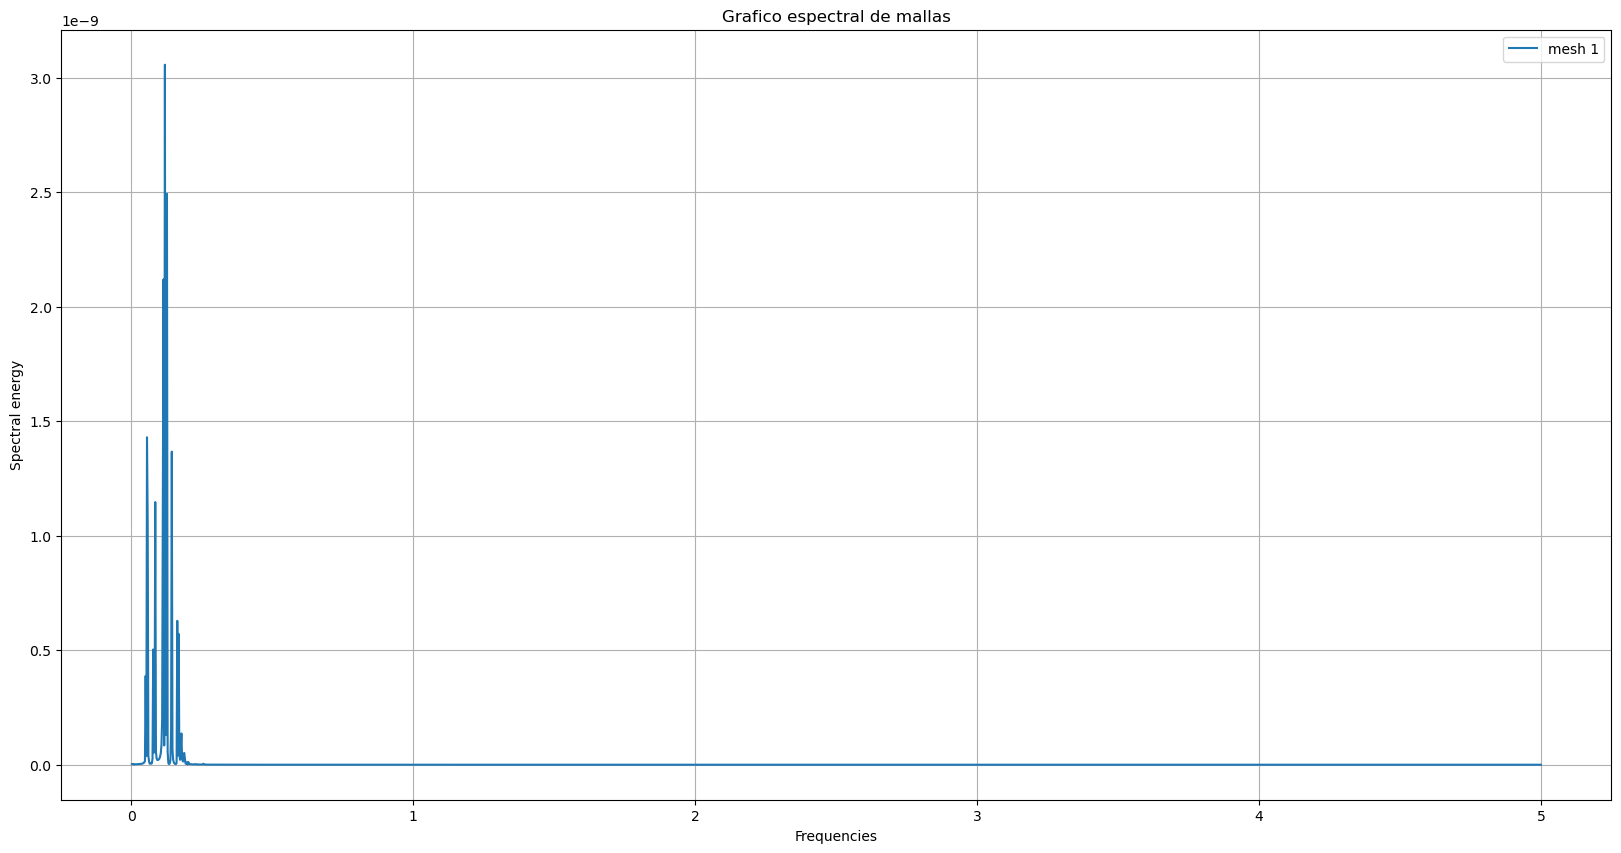

In [22]:
plt.figure(figsize=(20,10))
plt.plot(frequency, density, label = 'mesh 1')

plt.title('Grafico espectral de mallas')
plt.xlabel('Frequencies')
plt.ylabel('Spectral energy')
plt.legend()
plt.grid()

## bucle para representar todas las mallas

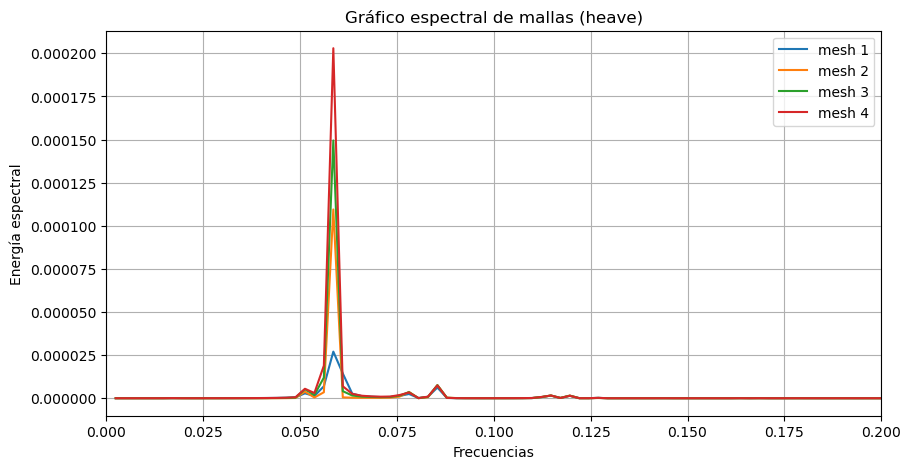

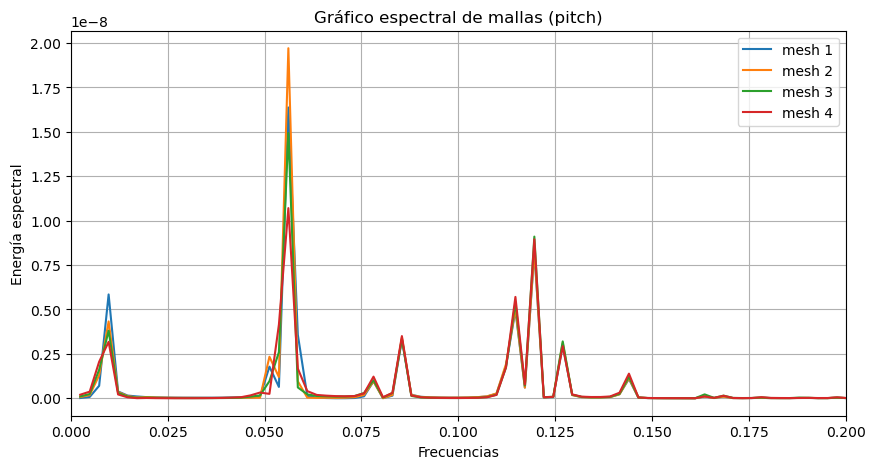

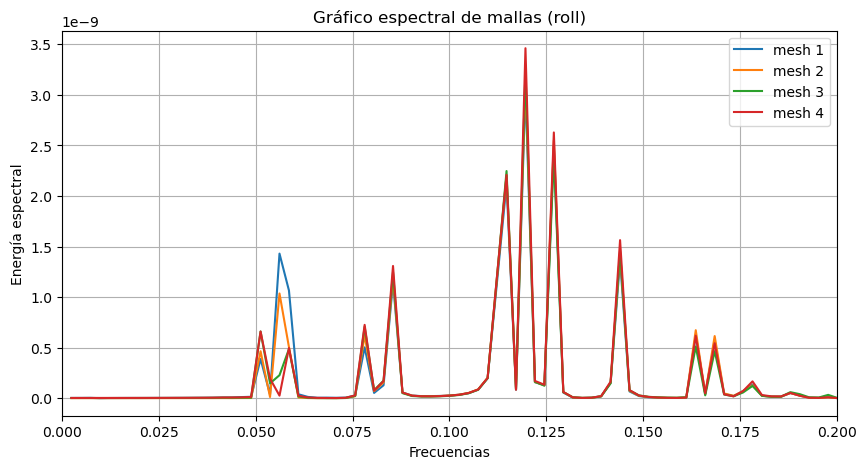

In [3]:
movements = ['heave','pitch','roll']

for mov in movements:
    frequencies_list = []
    density_list = []

    for mesh in range(0,4):
        path = rf'D:\arturo_sim\simulaciones\analisis_sensibilidad\data\mesh{mesh}_{mov}.xlsx'
        df = pd.read_excel(path, header = 1).drop(0)

        ancho_banda = df['Frequencies)'][2]-df['Frequencies)'][1]
        df['density'] = 0.5 * (df['Amplitude']**(2)*ancho_banda)
        

        frequency = df['Frequencies)'].values
        density = df['density'].values

        frequencies_list.append(frequency)
        density_list.append(density)


    plt.figure(figsize=(10, 5))
    for mesh, (frequency, density) in enumerate(zip(frequencies_list, density_list), start=1):
        plt.plot(frequency, density, label=f'mesh {mesh}')

    plt.xlim(0,0.2)
    plt.title(f'Gráfico espectral de mallas ({mov})')
    plt.xlabel('Frecuencias')
    plt.ylabel('Energía espectral')
    plt.legend()
    plt.grid()

    #plt.savefig(r'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\mesh_analysis\mesh_comparative.png', dpi=300, bbox_inches='tight')